# FEATURE SELECTION - VN INDEX

## Import libraries

In [48]:
import os
import sys
from datetime import datetime, timedelta
import pandas as pd
import lightning as L
import torch.nn as nn
import torch
from torch.optim import Adam
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from tsfresh.utilities.dataframe_functions import (
    roll_time_series,
)
from tsfresh import extract_features, select_features
from tsfresh.utilities.dataframe_functions import impute
from tsfresh.feature_extraction import ComprehensiveFCParameters, EfficientFCParameters
import matplotlib.pylab as plt
from sklearn.preprocessing import MinMaxScaler
from lightning.pytorch.callbacks import EarlyStopping
from dataclasses import asdict
import ipynbname
from sklearn.inspection import permutation_importance
import xgboost as xgb
import seaborn as sns
from tqdm import tqdm

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from logger.logger import Logger
from utils.constants import *
from dtos.config_dtos.config_dto import ConfigDto
from tabular_database_driver.postgre_sql_driver import PostgreSQLDriver
from dtos.tabular_database_driver_dtos.postgre_sql_connection_dto import (
    PostgreSQLConnectionDto,
)
from utils.enums import (
    LossFunctionType,
    ModelAchitectureType,
    OptimizerType,
    ScalerType,
)
from ta.ta_functions import *

## Helper functions

In [49]:
def get_weekends(from_date: str, to_date: str):
    start = datetime.strptime(from_date, "%Y-%m-%d")
    end = datetime.strptime(to_date, "%Y-%m-%d")

    weekends = []
    current = start

    while current <= end:
        if current.weekday() in (5, 6):  # 5 = Saturday, 6 = Sunday
            weekends.append(current.strftime("%Y-%m-%d"))
        current += timedelta(days=1)

    return weekends

## Parameters

In [50]:
NOTEBOOK_NAME = ipynbname.name()
RANDOM_SEED = 18
MAX_TIMESHIFT = 5
MIN_TIMESHIFT = 5
FORECAST_HORIZON = 5
COLUMN_ID = "stock"
TARGET_COLUMN = "return_5"
DATE_COLUMN = "date"
FEATURE_COLUMNS = []  # all TA indicators

# Inclusive
TRAIN_RANGE = ("2000-01-01", "2021-12-31")
VALIDATION_RANGE = ("2022-01-01", "2023-12-31")
TEST_RANGE = ("2024-01-01", "2026-02-26")

OUTPUT_SIZE = 1

In [51]:
WEEKENDS = get_weekends(TRAIN_RANGE[0], TEST_RANGE[1])
HOLIDAYS = []

DAYOFFS = []
DAYOFFS.extend(WEEKENDS)
DAYOFFS.extend(HOLIDAYS)

DAYOFFS[:10], DAYOFFS[-10:]

(['2000-01-01',
  '2000-01-02',
  '2000-01-08',
  '2000-01-09',
  '2000-01-15',
  '2000-01-16',
  '2000-01-22',
  '2000-01-23',
  '2000-01-29',
  '2000-01-30'],
 ['2026-01-24',
  '2026-01-25',
  '2026-01-31',
  '2026-02-01',
  '2026-02-07',
  '2026-02-08',
  '2026-02-14',
  '2026-02-15',
  '2026-02-21',
  '2026-02-22'])

## Load data

In [52]:
my_logger = Logger(file_name=f"{FEATURE_SELECTION_LOG_FILE_BASE}/vn_index/test")

In [53]:
my_connection_model = PostgreSQLConnectionDto(
    logger=my_logger,
    host=os.getenv("POSTGRES_HOST"),
    user=os.getenv("POSTGRES_USER"),
    password=os.getenv("POSTGRES_PASSWORD"),
    port=os.getenv("POSTGRES_PORT"),
    database=os.getenv("GOLD_POSTGRES_DATABASE"),
)

In [54]:
my_postgresql_driver = PostgreSQLDriver(logger=my_logger)
my_postgresql_driver.connect(my_connection_model)

<DatabaseExecutionStatus.SUCCESS: 'success'>

In [55]:
vn_index_df = my_postgresql_driver.select(
    schema_name="stock_market", table_name="vn_index"
)

In [56]:
dtype_map = {
    "date": str,
    "open": float,
    "high": float,
    "low": float,
    "close": float,
    "adjust": float,
    "change": float,
    "percent_change": float,
    "matching_volume": float,
    "matching_value": float,
    "negotiate_volume": float,
    "negotiate_value": float,
    "number_of_buy_orders": float,
    "buy_volume": float,
    "average_volume_per_buy_order": float,
    "number_of_sell_orders": float,
    "sell_volume": float,
    "average_volume_per_sell_order": float,
    "net_volume": float,
}

vn_index_df = (
    vn_index_df.astype(dtype_map)
    .dropna(subset=["close"])
    .sort_values(by=["date"])
    .reset_index(drop=True)
)

In [57]:
vn_index_df

,date,open,high,low,close,adjust,change,percent_change,matching_volume,matching_value,negotiate_volume,negotiate_value,number_of_buy_orders,buy_volume,average_volume_per_buy_order,number_of_sell_orders,sell_volume,average_volume_per_sell_order,net_volume
0,2008-03-07,640.140,640.140,640.140,640.140,640.140,28.970000,4.740000,8.169220e+06,5.152538e+11,350040.0,2.910304e+10,26816.0,5.268141e+07,1965.000000,3448.0,9.057040e+06,2627.0,4.362437e+07
1,2008-03-08,646.190,646.190,646.190,646.190,646.190,25.363333,4.106667,1.314382e+07,8.298321e+11,769057.0,4.594466e+10,27442.0,5.068024e+07,1852.333333,7486.0,1.712815e+07,2464.0,3.355209e+07
2,2008-03-09,652.240,652.240,652.240,652.240,652.240,21.756667,3.473333,1.811842e+07,1.144410e+12,1188073.0,6.278627e+10,28068.0,4.867907e+07,1739.666667,11523.0,2.519927e+07,2301.0,2.347980e+07
3,2008-03-10,658.290,658.290,658.290,658.290,658.290,18.150000,2.840000,2.309302e+07,1.458989e+12,1607090.0,7.962789e+10,28694.0,4.667790e+07,1627.000000,15561.0,3.327038e+07,2138.0,1.340752e+07
4,2008-03-11,638.710,638.710,638.710,638.710,638.710,-19.580000,-2.970000,1.384280e+07,8.374665e+11,226000.0,1.209960e+10,14464.0,1.933131e+07,1337.000000,17910.0,2.811427e+07,1570.0,-8.782960e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6561,2026-02-22,1832.317,1859.236,1829.801,1856.535,1856.535,33.445000,1.837000,7.158068e+08,2.227241e+13,23581058.0,7.924402e+11,476711.0,1.233848e+09,2591.300000,393692.0,1.198445e+09,3047.9,3.540296e+07
6562,2026-02-23,1833.900,1863.130,1833.900,1860.140,1860.140,36.050000,1.980000,7.313611e+08,2.264621e+13,23192200.0,7.774309e+11,486603.0,1.253004e+09,2575.000000,401281.0,1.213944e+09,3025.0,3.906029e+07
6563,2026-02-24,1862.180,1867.690,1849.600,1867.620,1867.620,7.480000,0.400000,9.667547e+08,3.120594e+13,22413147.0,7.795734e+11,598087.0,1.575227e+09,2634.000000,507471.0,1.648273e+09,3248.0,-7.304628e+07
6564,2026-02-25,1869.490,1876.010,1855.890,1860.910,1860.910,-6.710000,-0.360000,1.083635e+09,3.567852e+13,62225450.0,1.856894e+12,694266.0,1.862364e+09,2682.000000,597096.0,1.892734e+09,3170.0,-3.036983e+07


## Data transformation

In [58]:
vn_index_df.shape

(6566, 19)

### Remove DAYOFFS

In [59]:
vn_index_df_t1 = vn_index_df[~vn_index_df["date"].isin(DAYOFFS)]
vn_index_df_t1.shape

(4690, 19)

### Calculate return

In [60]:
vn_index_df_t2 = vn_index_df_t1.copy()
vn_index_df_t2[f"return_{FORECAST_HORIZON}"] = (
    vn_index_df_t2["close"].shift(-FORECAST_HORIZON) - vn_index_df_t1["close"]
)
# vn_index_df_t2[f"log_return_{FORECAST_HORIZON}"] = np.log(
#     vn_index_df_t2["close"].shift(-FORECAST_HORIZON) / vn_index_df_t2["close"]
# )
vn_index_df_t2 = vn_index_df_t2.dropna(how="any").reset_index(drop=True)
vn_index_df_t2.shape

(4685, 20)

In [61]:
vn_index_df_t_final = vn_index_df_t2
vn_index_df_t_final.shape

(4685, 20)

## Create features

In [62]:
FUNCTION_NAME = "add_bbands"
FUNCTION_NAME

'add_bbands'

In [63]:
vn_index_df_cf1 = add_bbands(vn_index_df_t_final, n=[5, 10, 15, 20])
vn_index_df_cf1.shape

(4685, 112)

In [64]:
vn_index_df_cf_final = vn_index_df_cf1
vn_index_df_cf_final.shape

(4685, 112)

## Filter columns

In [65]:
FEATURE_COLUMNS = list(
    vn_index_df_cf_final.columns.drop(
        [
            DATE_COLUMN,
            TARGET_COLUMN,
        ]
    )
)
len(FEATURE_COLUMNS)

110

## Feature Importance

In [66]:
input_df = vn_index_df_cf_final
input_df.shape

(4685, 112)

In [67]:
TOP_N = 50

In [68]:
len(FEATURE_COLUMNS)

110

In [69]:
TARGET_COLUMN

'return_5'

### Model

In [70]:
n_estimators = 10
max_depth = 4
learning_rate = 0.05
subsample = 0.8
colsample_bytree = 0.8
tree_method = "hist"

In [71]:
# Convert date
input_df[DATE_COLUMN] = pd.to_datetime(input_df[DATE_COLUMN])

# -----------------------------
# TRAIN DATA
# -----------------------------
X = input_df[FEATURE_COLUMNS]
y = input_df[TARGET_COLUMN]


# -----------------------------
# GPU XGBOOST MODEL
# -----------------------------
model = xgb.XGBRegressor(
    n_estimators=n_estimators,
    max_depth=max_depth,
    learning_rate=learning_rate,
    subsample=subsample,
    colsample_bytree=colsample_bytree,
    tree_method=tree_method,
    random_state=RANDOM_SEED,
)

model.fit(X, y, verbose=True)  # already gives iteration logs

# -----------------------------
# PERMUTATION IMPORTANCE
# -----------------------------
result = permutation_importance(
    model,
    X,
    y,
    n_repeats=40,
    random_state=RANDOM_SEED,
    n_jobs=16,
    scoring="neg_mean_squared_error",
)

# -----------------------------
# CREATE IMPORTANCE DF
# -----------------------------
importance_df = pd.DataFrame(
    {"feature": FEATURE_COLUMNS, "importance": result.importances_mean}
).sort_values("importance", ascending=False)

importance_df["importance_pct"] = (
    importance_df["importance"] / importance_df["importance"].sum() * 100
)

print("\nFeature Importance:")
print(importance_df)


Feature Importance:
                                   feature  importance  importance_pct
13            average_volume_per_buy_order   27.639030       24.611132
89                       close_bb_20_lower   21.403120       19.058375
41                       close_bb_10_upper    6.088724        5.421695
64                       close_bb_15_upper    3.442176        3.065080
72                close_bb_15_slope_middle    3.136569        2.792953
..                                     ...         ...             ...
62                close_bb_10_inside_bands    0.000000        0.000000
63                    close_bb_10_position    0.000000        0.000000
68                 close_bb_15_dist_middle    0.000000        0.000000
73   close_bb_15_slope_middle_acceleration    0.000000        0.000000
109                   close_bb_20_position    0.000000        0.000000

[110 rows x 3 columns]


In [72]:
importance_df

,feature,importance,importance_pct
13,average_volume_per_buy_order,27.639030,24.611132
89,close_bb_20_lower,21.403120,19.058375
41,close_bb_10_upper,6.088724,5.421695
64,close_bb_15_upper,3.442176,3.065080
72,close_bb_15_slope_middle,3.136569,2.792953
...,...,...,...
62,close_bb_10_inside_bands,0.000000,0.000000
63,close_bb_10_position,0.000000,0.000000
68,close_bb_15_dist_middle,0.000000,0.000000
73,close_bb_15_slope_middle_acceleration,0.000000,0.000000


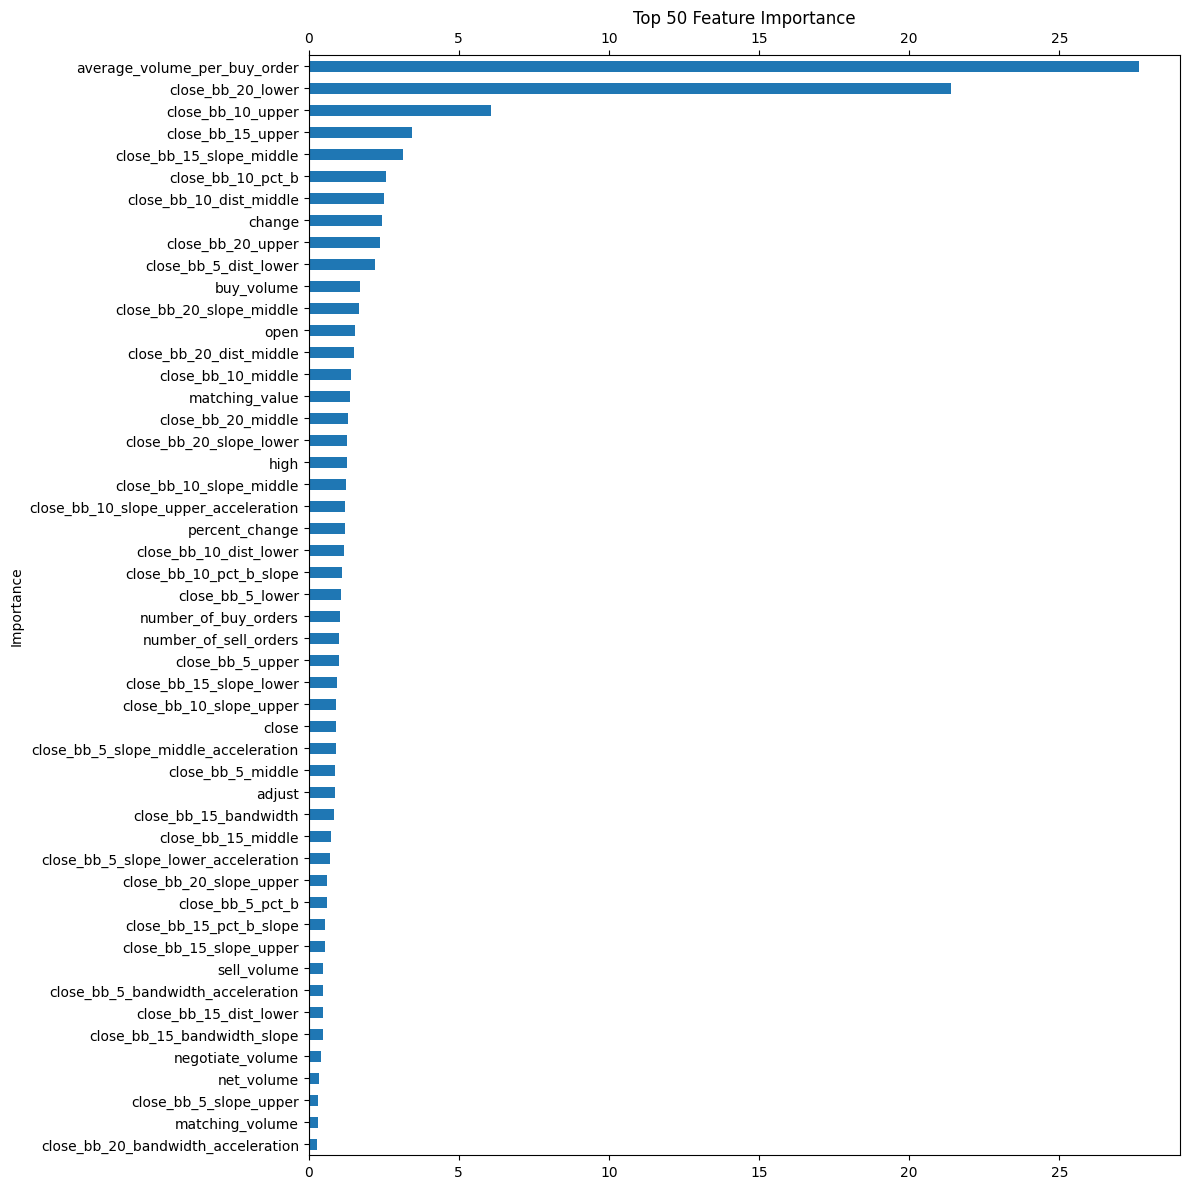

In [73]:
top_features = (
    importance_df.sort_values("importance", ascending=False)
    .head(TOP_N)
    .set_index("feature")["importance"]
).sort_values(ascending=True)

# Plot
ax = top_features.plot(kind="barh", figsize=(12, 12))

plt.title(f"Top {TOP_N} Feature Importance")
plt.ylabel("Importance")

# Show x ticks on both top and bottom
ax.xaxis.set_ticks_position("both")
ax.tick_params(axis="x", which="both", top=True, bottom=True, labeltop=True)

plt.tight_layout()
plt.show()

In [74]:
TOP_N_FEATURES = list(top_features.index)
TOP_N_FEATURES

['close_bb_20_bandwidth_acceleration',
 'matching_volume',
 'close_bb_5_slope_upper',
 'net_volume',
 'negotiate_volume',
 'close_bb_15_bandwidth_slope',
 'close_bb_15_dist_lower',
 'close_bb_5_bandwidth_acceleration',
 'sell_volume',
 'close_bb_15_slope_upper',
 'close_bb_15_pct_b_slope',
 'close_bb_5_pct_b',
 'close_bb_20_slope_upper',
 'close_bb_5_slope_lower_acceleration',
 'close_bb_15_middle',
 'close_bb_15_bandwidth',
 'adjust',
 'close_bb_5_middle',
 'close_bb_5_slope_middle_acceleration',
 'close',
 'close_bb_10_slope_upper',
 'close_bb_15_slope_lower',
 'close_bb_5_upper',
 'number_of_sell_orders',
 'number_of_buy_orders',
 'close_bb_5_lower',
 'close_bb_10_pct_b_slope',
 'close_bb_10_dist_lower',
 'percent_change',
 'close_bb_10_slope_upper_acceleration',
 'close_bb_10_slope_middle',
 'high',
 'close_bb_20_slope_lower',
 'close_bb_20_middle',
 'matching_value',
 'close_bb_10_middle',
 'close_bb_20_dist_middle',
 'open',
 'close_bb_20_slope_middle',
 'buy_volume',
 'close_bb_

## Feature Selection

In [75]:
CORR_THRESHOLD = 0.95

# Correlation matrix (absolute values)
corr_matrix = input_df[FEATURE_COLUMNS].corr().abs()

# Features sorted by importance
sorted_features = importance_df.sort_values("importance", ascending=False)[
    "feature"
].tolist()

selected_features = []
removed_features = set()

for feature in sorted_features:

    if feature in removed_features:
        continue

    selected_features.append(feature)

    # Find correlated features
    correlated = corr_matrix.index[corr_matrix[feature] > CORR_THRESHOLD].tolist()

    for corr_feature in correlated:
        if corr_feature != feature:
            removed_features.add(corr_feature)

print("Selected features:", len(selected_features))
print("Removed features:", len(removed_features))

print("\nTop kept features:")
print(selected_features[:TOP_N])

print("\nRemoved features:")
print(list(removed_features))

Selected features: 79
Removed features: 31

Top kept features:
['average_volume_per_buy_order', 'close_bb_20_lower', 'close_bb_15_slope_middle', 'close_bb_10_pct_b', 'close_bb_10_dist_middle', 'change', 'close_bb_5_dist_lower', 'buy_volume', 'close_bb_20_slope_middle', 'close_bb_20_dist_middle', 'matching_value', 'close_bb_20_slope_lower', 'close_bb_10_slope_middle', 'close_bb_10_slope_upper_acceleration', 'percent_change', 'close_bb_10_dist_lower', 'close_bb_10_pct_b_slope', 'number_of_buy_orders', 'close_bb_15_slope_lower', 'close_bb_10_slope_upper', 'close_bb_5_slope_middle_acceleration', 'close_bb_15_bandwidth', 'close_bb_5_slope_lower_acceleration', 'close_bb_20_slope_upper', 'close_bb_5_pct_b', 'close_bb_15_pct_b_slope', 'close_bb_15_slope_upper', 'close_bb_5_bandwidth_acceleration', 'close_bb_15_dist_lower', 'close_bb_15_bandwidth_slope', 'negotiate_volume', 'net_volume', 'close_bb_5_slope_upper', 'close_bb_20_bandwidth_acceleration', 'close_bb_20_slope_upper_acceleration', 'clo

## Feature Correlation

Correlation Matrix:


,average_volume_per_buy_order,close_bb_20_lower,close_bb_15_slope_middle,close_bb_10_pct_b,close_bb_10_dist_middle,change,close_bb_5_dist_lower,buy_volume,close_bb_20_slope_middle,close_bb_20_dist_middle,...,close_bb_15_slope_upper_acceleration,close_bb_5_slope_middle,average_volume_per_sell_order,close_bb_10_slope_middle_acceleration,close_bb_5_bandwidth,close_bb_5_bandwidth_slope,close_bb_5_pct_b_slope,close_bb_5_pct_b_gt_1,close_bb_5_pct_b_lt_0,close_bb_5_above_upper
average_volume_per_buy_order,1.000000,-0.087028,0.156673,0.224991,0.189459,0.146316,-0.011279,0.186018,0.156898,0.190133,...,0.007166,0.155123,0.850126,0.074507,-0.204711,0.003736,0.071048,NaN,-0.019524,NaN
close_bb_20_lower,-0.087028,1.000000,0.087489,0.048991,0.005143,0.015056,-0.152986,0.728220,0.122458,0.028167,...,-0.000815,0.031859,0.115574,-0.014731,-0.198922,0.007122,-0.002342,NaN,-0.016247,NaN
close_bb_15_slope_middle,0.156673,0.087489,1.000000,0.543184,0.628178,0.276747,0.114353,0.202135,0.875466,0.838140,...,0.042014,0.586753,0.071169,-0.034301,-0.283456,-0.016949,-0.030349,NaN,-0.028628,NaN
close_bb_10_pct_b,0.224991,0.048991,0.543184,1.000000,0.813368,0.516985,0.437636,0.112241,0.457223,0.694742,...,0.096616,0.751023,-0.007351,0.337857,-0.193786,-0.084279,0.130017,NaN,-0.015971,NaN
close_bb_10_dist_middle,0.189459,0.005143,0.628178,0.813368,1.000000,0.480984,0.489410,0.087143,0.533820,0.874914,...,0.072960,0.831526,-0.035941,0.316666,-0.236625,-0.092318,0.030577,NaN,-0.022506,NaN
change,0.146316,0.015056,0.276747,0.516985,0.480984,1.000000,0.424025,0.047649,0.232399,0.342800,...,0.005500,0.495242,-0.097145,0.679210,-0.098063,-0.200262,0.570592,NaN,-0.009033,NaN
close_bb_5_dist_lower,-0.011279,-0.152986,0.114353,0.437636,0.489410,0.424025,1.000000,-0.011732,0.072410,0.328617,...,0.061708,0.390392,-0.203161,0.325469,0.645728,0.078445,0.172316,NaN,-0.014282,NaN
buy_volume,0.186018,0.728220,0.202135,0.112241,0.087143,0.047649,-0.011732,1.000000,0.220855,0.115231,...,-0.020583,0.122866,0.269250,-0.013394,-0.074732,0.017117,-0.019703,NaN,-0.011400,NaN
close_bb_20_slope_middle,0.156898,0.122458,0.875466,0.457223,0.533820,0.232399,0.072410,0.220855,1.000000,0.765582,...,-0.006624,0.494059,0.096445,-0.037867,-0.274141,-0.018865,-0.024772,NaN,-0.031223,NaN
close_bb_20_dist_middle,0.190133,0.028167,0.838140,0.694742,0.874914,0.342800,0.328617,0.115231,0.765582,1.000000,...,0.045045,0.671155,0.023507,0.092063,-0.236128,-0.045873,-0.015191,NaN,-0.040339,NaN


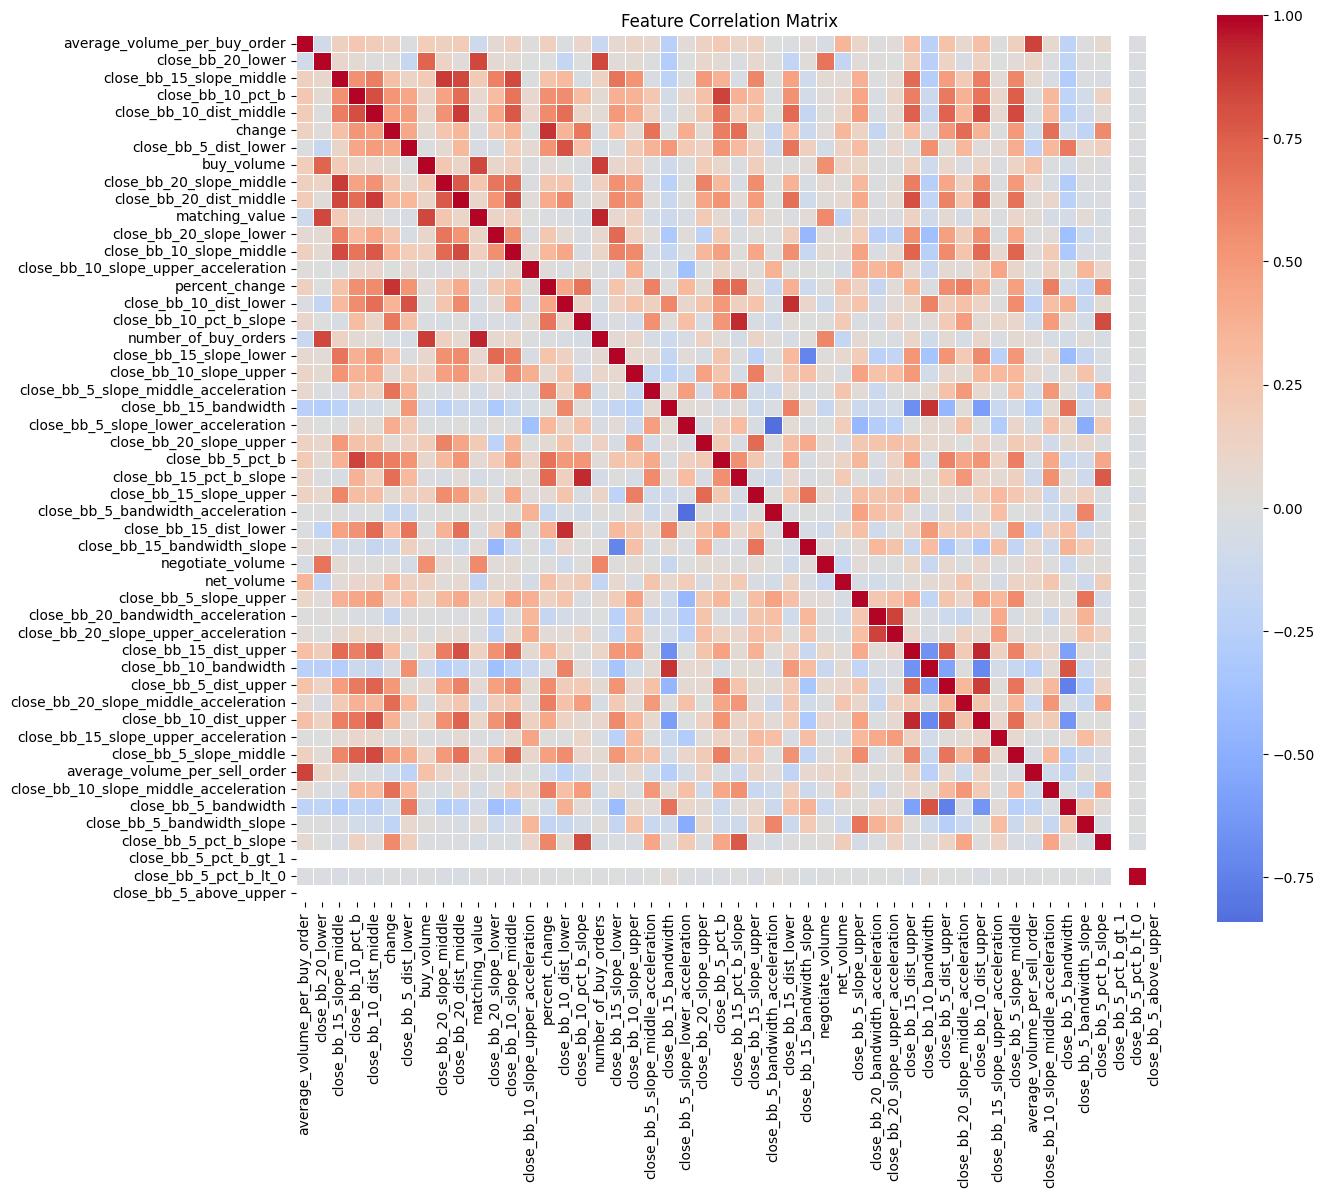

In [76]:
corr_matrix = input_df[selected_features[:TOP_N]].corr()

print("Correlation Matrix:")
display(corr_matrix)

# -----------------------------
# HEATMAP VISUALIZATION
# -----------------------------
plt.figure(figsize=(14, 12))

sns.heatmap(corr_matrix, cmap="coolwarm", center=0, square=True, linewidths=0.5)

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [77]:
FINAL_FEATURE_COLUMNS = selected_features[:TOP_N]

print("Original feature count:", len(FEATURE_COLUMNS))
print("Final feature count:", len(FINAL_FEATURE_COLUMNS))

X_fs = input_df[FINAL_FEATURE_COLUMNS].dropna().reset_index(drop=True)
X_fs

Original feature count: 110
Final feature count: 50


,average_volume_per_buy_order,close_bb_20_lower,close_bb_15_slope_middle,close_bb_10_pct_b,close_bb_10_dist_middle,change,close_bb_5_dist_lower,buy_volume,close_bb_20_slope_middle,close_bb_20_dist_middle,...,close_bb_15_slope_upper_acceleration,close_bb_5_slope_middle,average_volume_per_sell_order,close_bb_10_slope_middle_acceleration,close_bb_5_bandwidth,close_bb_5_bandwidth_slope,close_bb_5_pct_b_slope,close_bb_5_pct_b_gt_1,close_bb_5_pct_b_lt_0,close_bb_5_above_upper
0,2104.0,456.437563,-4.892000,0.941532,0.044897,9.330,0.051991,3.828609e+07,-5.79800,-0.029237,...,6.330358,5.096,1972.0,3.3940,0.055099,0.011413,0.070382,False,False,False
1,2242.0,458.721207,-2.646667,0.948322,0.046433,6.230,0.058124,4.653044e+07,-4.50750,-0.010098,...,8.608944,5.514,2093.0,3.0660,0.064293,0.009194,-0.042610,False,False,False
2,1995.0,463.461669,-1.426667,0.907185,0.043658,3.490,0.054502,2.034775e+07,-4.59250,0.004524,...,4.897415,5.388,1600.0,-0.4540,0.064753,0.000461,-0.060552,False,False,False
3,2547.0,471.050258,-1.272667,0.747339,0.024547,-6.320,0.027128,1.112623e+07,-5.09350,0.002314,...,1.018197,3.300,1757.0,-1.0400,0.047829,-0.016924,-0.260819,False,False,False
4,2477.0,481.669041,-0.444667,0.581048,0.006957,-6.720,0.004878,1.000545e+07,-5.23950,-0.000409,...,3.966721,1.202,1801.0,-1.0670,0.033517,-0.014312,-0.410525,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4659,2738.0,1734.009671,-3.113333,0.843960,0.019429,10.000,0.054367,1.061450e+09,-2.75200,0.001044,...,3.107776,13.720,3254.0,-0.4060,0.065679,0.008377,-0.083179,False,False,False
4660,2689.1,1737.479351,-0.587667,0.875738,0.023847,17.815,0.049605,1.118916e+09,-3.08425,0.008687,...,10.198164,16.017,3185.3,3.3355,0.062730,-0.002949,-0.034611,False,False,False
4661,2672.8,1741.560768,0.534000,0.851481,0.024424,20.420,0.026232,1.138071e+09,-2.76350,0.012206,...,4.127167,16.896,3162.4,-0.3295,0.033128,-0.029603,0.012761,False,False,False
4662,2656.5,1745.245894,2.613667,0.809628,0.023542,23.025,0.017643,1.157227e+09,-2.16625,0.015402,...,4.485377,9.053,3139.5,2.5575,0.022464,-0.010663,-0.002195,False,False,False


## Save Data

### Create Result Folder

In [78]:
FEATURE_SELECTION_RESULT_DIR

'../../src/feature_selection/feature_selection_result'

In [79]:
os.makedirs(FEATURE_SELECTION_RESULT_DIR, exist_ok=True)

In [80]:
FUNCTION_NAME

'add_bbands'

In [81]:
importance_df

,feature,importance,importance_pct
13,average_volume_per_buy_order,27.639030,24.611132
89,close_bb_20_lower,21.403120,19.058375
41,close_bb_10_upper,6.088724,5.421695
64,close_bb_15_upper,3.442176,3.065080
72,close_bb_15_slope_middle,3.136569,2.792953
...,...,...,...
62,close_bb_10_inside_bands,0.000000,0.000000
63,close_bb_10_position,0.000000,0.000000
68,close_bb_15_dist_middle,0.000000,0.000000
73,close_bb_15_slope_middle_acceleration,0.000000,0.000000


In [82]:
importance_df.to_csv(
    os.path.join(FEATURE_SELECTION_RESULT_DIR, f"{FUNCTION_NAME}_importance.csv"),
    header=True,
    index=False,
)